# EDA And Preprocessing

## Data Loader

In [1]:
from dataset import CellPaintingDataset
from torch.utils.data import DataLoader

dataset = CellPaintingDataset(
    metadata_path="../data/processed/master_metadata.parquet",
    data_root="../data",
    channels=[1,2,3,4,5],
    tile_size=224
)

print("Num fields:", len(dataset.fields))   # ~14 or however many you have
print("Num tiles:", len(dataset))           # fields × 16

sample = dataset[0]
x = sample["image"]
print("Shape:", x.shape)        # should be (5, 224, 224)
print("Min:", x.min().item())
print("Max:", x.max().item())

Final valid fields: 864
Num fields: 5
Num tiles: 100000
Shape: torch.Size([5, 224, 224])
Min: -0.027771446853876114
Max: 1.1324238777160645


In [2]:
loader = DataLoader(dataset, batch_size=4, shuffle=True)

for batch in loader:
    print(batch["image"].shape)
    print(batch["compound"][:3])
    break

torch.Size([4, 5, 224, 224])
['gabapentin-enacarbil', 'gabapentin-enacarbil', 'gabapentin-enacarbil']


## EDA

Note that:
* Ch1 Mito Mitochondria
* Ch2 AGP Actin, Golgi, Plasma membrane
* Ch3 RNA / Nucleoli
* Ch4 ER Endoplasmic Reticulum
* Ch5 DNA Nucleus (Hoechst 33342)


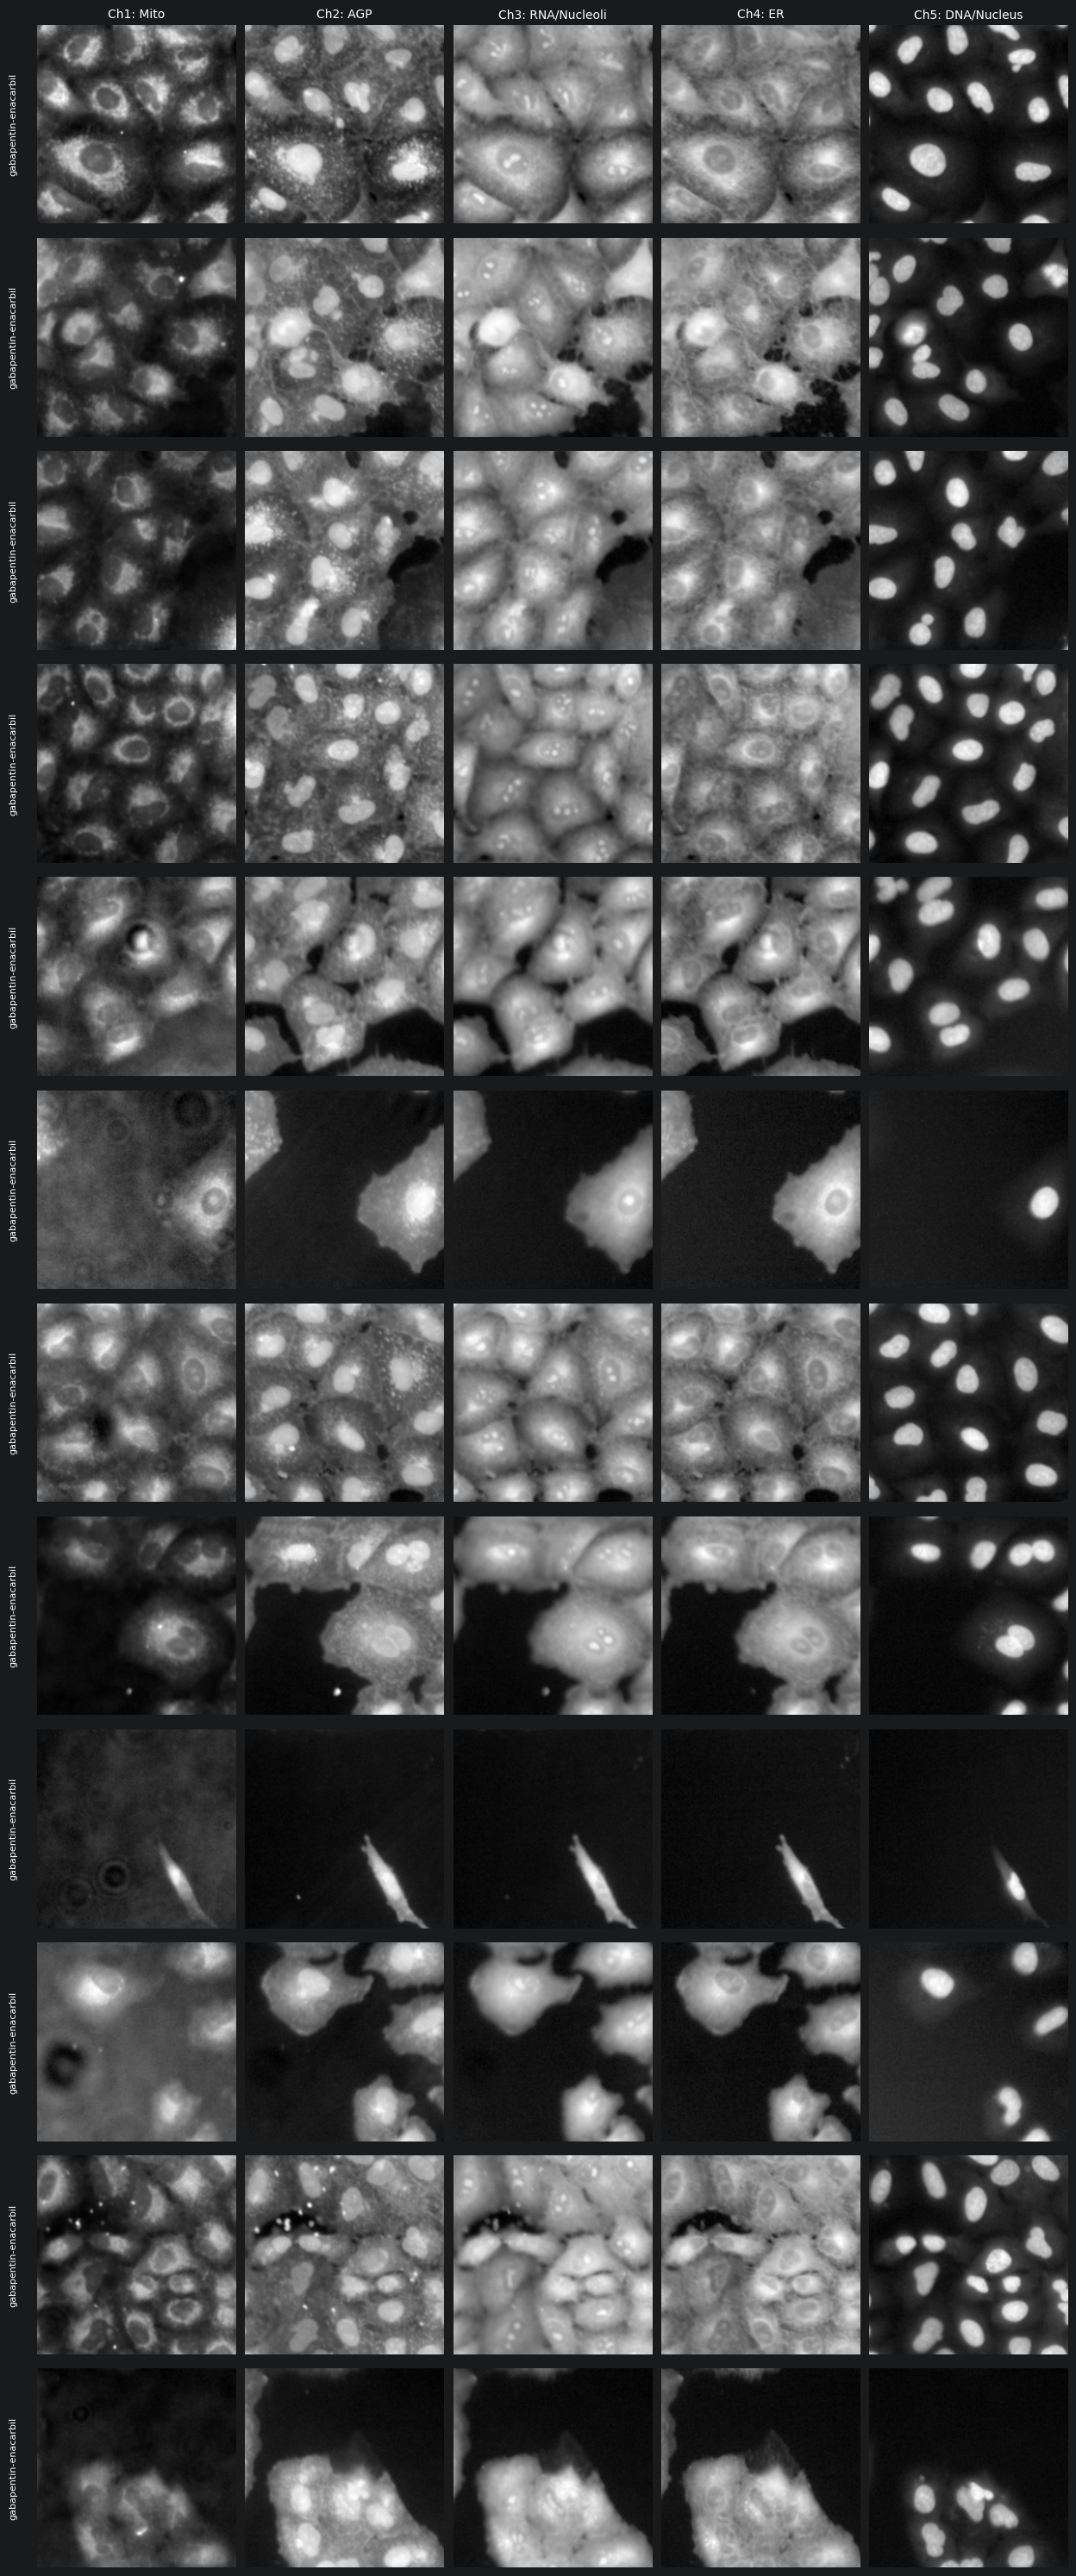

In [3]:
import matplotlib.pyplot as plt

def plot_grid(dataset, n=6, channel_names=None):

    sample = dataset[0]["image"]
    n_channels = sample.shape[0]

    fig, axes = plt.subplots(
        n, n_channels,
        figsize=(2.5 * n_channels, 2.5 * n)
    )

    if channel_names is None:
        channel_names = [f"Channel {c+1}" for c in range(n_channels)]

    for i in range(n):

        sample = dataset[i]
        x = sample["image"]

        for c in range(n_channels):
            ax = axes[i, c]

            ax.imshow(x[c], cmap="gray")
            ax.set_axis_off()

            if i == 0:
                ax.set_title(channel_names[c], fontsize=10)

        axes[i, 0].text(
            -0.1, 0.5,
            f"{sample['compound']}",
            rotation=90,
            transform=axes[i, 0].transAxes,
            va="center",
            ha="right",
            fontsize=8
        )

    plt.tight_layout()
    plt.show()

channels = ["Ch1: Mito", "Ch2: AGP", "Ch3: RNA/Nucleoli", "Ch4: ER", "Ch5: DNA/Nucleus"]

plot_grid(dataset, n=12, channel_names=channels)

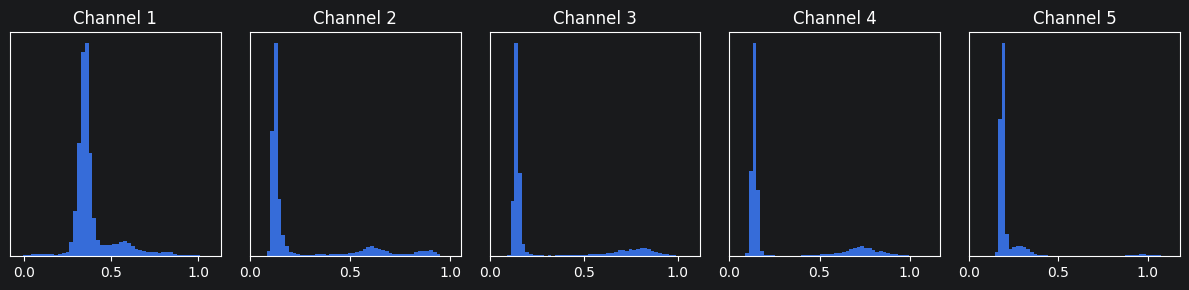

In [4]:
# Intensity distributions to check for normalization and corruption
import numpy as np

def plot_intensity_histograms(x):
    plt.figure(figsize=(12, 3))

    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.hist(x[i].flatten(), bins=50)
        plt.title(f"Channel {i+1}")
        plt.xticks([0, 0.5, 1])
        plt.yticks([])

    plt.tight_layout()
    plt.show()

plot_intensity_histograms(x)

100%|██████████| 500/500 [00:01<00:00, 426.56it/s]


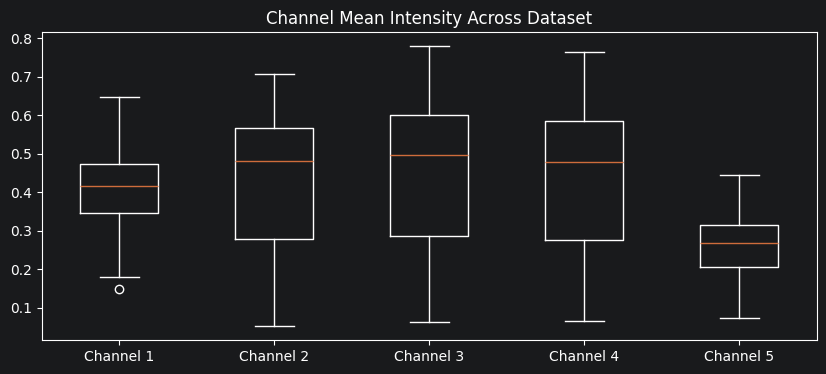

In [5]:
from tqdm import tqdm

# Subset-wide channel statistics
means = []
stds = []

subset = np.random.choice(len(dataset), min(len(dataset), 500), replace=False)

for i in tqdm(subset):
    sample = dataset[i]
    x = sample["image"]
    means.append(x.mean(dim=(1,2)).numpy())
    stds.append(x.std(dim=(1,2)).numpy())

means = np.stack(means)
stds = np.stack(stds)

plt.figure(figsize=(10,4))
plt.title("Channel Mean Intensity Across Dataset")
plt.boxplot(means)
plt.xticks(range(1,6), [f"Channel {i}" for i in range(1,6)])
plt.show()